In [1]:
!pip install ml4eft
!pip install wget
!lhapdf install NNPDF31_lo_as_0118

PDF already installed: NNPDF31_lo_as_0118 (use --upgrade to force install)


In [7]:
import wget
import tarfile
import os
import time
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
from matplotlib import rc
import sys
import json
import numpy.core.numeric as numeric
sys.modules["numpy._core.numeric"] = numeric

import ml4eft.core.classifier as classifier
import ml4eft.analyse.analyse as analyse
from ml4eft.analyse.animate import Animate
import ml4eft.plotting.features as features
import ml4eft.preproc.constants as constants

import types
sys.modules['pymultinest'] = types.ModuleType('pymultinest')
import ml4eft.limits.optimize_ns as optimize

mt = constants.mt

rc('text', usetex=False)
rc('font', **{'family': 'DejaVu Sans', 'size': 22})
plt.rcParams.update({'font.size': 12})

In [8]:
# Files that the ML trains on, will load these in from the path given in the json not from these variable names directly
# For the ML to find the fill, must follow format for quad: {path to dir}/tt_{WC name 1}_{WC name 2}/events_0.pkl
# df_sm is used for theory calculations

df_sm = pd.read_pickle("/depot/cms/top/jpittard/Purdue_Analysis_EFT/pickel_files/sm_quad_pickles/tt_sm/events_0.pkl.gz")
df_ctgre = pd.read_pickle("/depot/cms/top/jpittard/Purdue_Analysis_EFT/pickel_files/sm_quad_pickles/tt_ctGRe_ctGRe/events_0.pkl.gz")
df_ctu8 = pd.read_pickle("/depot/cms/top/jpittard/Purdue_Analysis_EFT/pickel_files/sm_quad_pickles/tt_ctu8_ctu8/events_0.pkl.gz")
df_ctgre_ctu8 = pd.read_pickle("/depot/cms/top/jpittard/Purdue_Analysis_EFT/pickel_files/sm_quad_pickles/tt_ctGRe_ctu8/events_0.pkl.gz")
df_ctu8_ctGRe = pd.read_pickle("/depot/cms/top/jpittard/Purdue_Analysis_EFT/pickel_files/sm_quad_pickles/tt_ctu8_ctGRe/events_0.pkl.gz")

df_sm = df_sm.iloc[1:, :]
df_ctgre = df_ctgre.iloc[1:,:]
df_ctu8 = df_ctu8.iloc[1:,:]
df_ctgre_ctu8 = df_ctgre_ctu8.iloc[1:,:]
df_ctu8_ctGRe = df_ctu8_ctGRe.iloc[1:,:]

df_sm

,gen_ttbar_mass,gen_ll_cHel,gen_c_nn,gen_llbar_delta_phi,gen_b1k,gen_b2k,gen_c_kk,gen_c_rr,gen_top_rapidity,gen_tbar_rapidity,gen_ttbar_rapidity,gen_llbar_pt,gen_l_eta
1,452.056213,0.395839,-0.153623,2.287395,0.232250,0.653464,0.151767,-0.393983,0.723339,-0.051309,0.346507,83.433952,0.133671
2,533.178589,-0.005817,-0.017134,2.386693,-0.944949,0.147334,-0.139223,0.162173,-0.962700,0.618691,-0.170593,12.436652,3.074899
3,521.388428,-0.791841,0.550000,2.894406,0.332672,0.790528,0.262986,-0.021146,-1.104894,-1.715219,-1.422506,54.844101,-1.834829
4,370.007294,0.401694,-0.204149,0.586303,0.208231,-0.975409,-0.203111,0.005566,-1.330552,-0.748295,-1.029508,80.075134,-2.088151
5,376.301422,-0.284160,-0.068622,1.721789,0.345912,-0.703454,-0.243333,0.596115,2.941606,2.316050,2.628273,43.090248,2.409710
...,...,...,...,...,...,...,...,...,...,...,...,...,...
14999995,458.779205,-0.271018,-0.359318,0.835493,-0.751825,-0.769717,0.578692,0.051644,-2.302757,-1.310471,-1.785987,67.149628,-1.616028
14999996,384.071655,0.285846,-0.081772,1.646844,0.422318,0.643182,0.271628,-0.475701,-0.965718,-1.302317,-1.165434,124.364632,-1.087390
14999997,417.781250,-0.062843,0.343436,1.917127,0.640183,-0.378034,-0.242011,-0.038581,-0.558663,-1.529769,-1.038660,51.900429,-1.274219
14999998,357.700775,-0.051848,-0.092560,1.656139,0.904207,0.040945,0.037023,0.107385,0.010436,-0.245439,-0.117620,52.873329,-0.503949


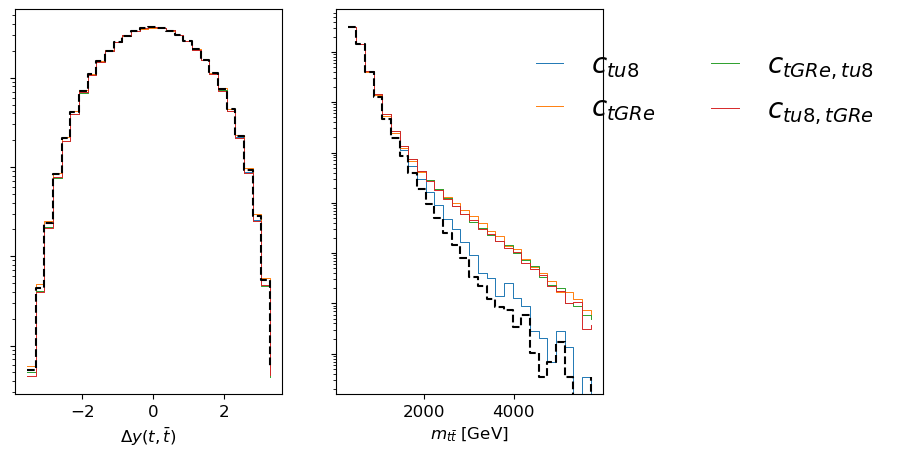

In [9]:
#Plots feature vectors for files loaded in

sub_features_dict = {
    #'gen_ttbar_pt': r'$p_T^{t\bar{t}}\;[\mathrm{GeV}]$',
    #'gen_ttbar_phi': r'$\phi_{t\bar{t}}$',
    #'gen_ttbar_rapidity': r'$y_{t\bar{t}}$',
    #'gen_ttbar_eta': r'$\eta_{t\bar{t}}$',
    #'gen_ttbar_delta_phi': r'$\Delta\phi(t,\bar{t})$',
    #'gen_ttbar_delta_eta': r'$\Delta\eta(t,\bar{t})$',
    'gen_ttbar_rapidity': r'$\Delta y(t,\bar{t})$',
    'gen_ttbar_mass': r'$m_{t\bar{t}}\;[\mathrm{GeV}]$',
    #'gen_llbar_delta_phi': r'$\Delta\phi(\ell,\bar{\ell})$'
}
legend_labels = [r'$c_{tu8}$', r'$c_{tGRe}$',r'$c_{tGRe,tu8}$',r'$c_{tu8,tGRe}$']

df_eft_list = [df_ctgre,df_ctu8,df_ctgre_ctu8,df_ctu8_ctGRe]

fig = features.plot_features(df_sm, df_eft_list, sub_features_dict, legend_labels);

In [10]:
# Loads in ML4EFT json runcard for the ML
def file_downloader(url, download_dir='./downloads'):
    if not os.path.exists(download_dir):
        os.mkdir(download_dir)
    file = wget.download(url, out=download_dir)
    return file

path_to_runcard = 'https://dl.dropboxusercontent.com/s/v4ulo6icveh63fw/run_card_tt_llvlvlbb.json?dl=0'
runcard = file_downloader(path_to_runcard)

In [11]:
#Changing the loss function that ML4EFT uses to a weighted loss

def new_loss_fn(self, outputs, labels, w_e):
    import torch

    eps = 1e-7
    outputs = torch.clamp(outputs, eps, 1 - eps)

    if self.loss_type == 'CE':

        loss = - (1 - labels) * w_e * torch.log(1 - outputs) \
               - labels * w_e * torch.log(outputs)

    elif self.loss_type == 'QC':

        loss = (1 - labels) * w_e * outputs ** 2 \
             + labels * w_e * (1 - outputs) ** 2

    return torch.sum(loss) / torch.sum(w_e)

classifier.Fitter.loss_fn = new_loss_fn

In [12]:
# Selecting what features to train the ML on
# ML4EFT CAN ONLY CALCULATE THE DIFFERENTIAL CROSS-SECTION FOR MTTBAR AND Y !!!!
# Must be features avalible in the files used

ML_features = [
#'gen_ttbar_pt',
#'gen_ttbar_phi',
'gen_ttbar_rapidity',
#'gen_ttbar_eta',
#'gen_ttbar_delta_phi',
#'gen_ttbar_delta_eta',
#'gen_ttbar_delta_rapidity',
'gen_ttbar_mass',
#'gen_llbar_pt',
#'gen_l_eta',
]

In [13]:
# Changing parameters of the json file
# 'features' is the previously defined features the ML will train on
# 'event_data' is the files that will be used to train the ML
# 'c_train' is the WC inputs and the corresponding value

with open(runcard) as json_runcard:
    json_runcard_loaded = json.load(json_runcard)
    
json_runcard_loaded['features'] = ML_features
json_runcard_loaded['event_data'] = '/depot/cms/top/jpittard/Purdue_Analysis_EFT/pickel_files/sm_quad_pickles'
json_runcard_loaded['c_train'] = {'ctGRe': 2,'ctu8': 2, 'ctGRe_ctu8': 2, 'ctu8_ctGRe': 2}
json_runcard_loaded['epochs'] = 30
json_runcard_loaded['lr'] = 0.01
json_runcard_loaded['n_batches'] = 10  # Original: 50
json_runcard_loaded['patience'] = 15
json_runcard_loaded['n_dat'] = 1000000 # Original: 100000
json_runcard_loaded

{'process_id': 'tt',
 'epochs': 30,
 'lr': 0.01,
 'n_batches': 10,
 'output_size': 1,
 'hidden_sizes': [100, 100, 100],
 'n_dat': 1000000,
 'event_data': '/depot/cms/top/jpittard/Purdue_Analysis_EFT/pickel_files/sm_quad_pickles',
 'features': ['gen_ttbar_rapidity', 'gen_ttbar_mass'],
 'loss_type': 'CE',
 'scaler_type': 'robust',
 'patience': 15,
 'val_ratio': 0.2,
 'c_train': {'ctGRe': 2, 'ctu8': 2, 'ctGRe_ctu8': 2, 'ctu8_ctGRe': 2}}

In [71]:
# 'output_dir', file location to save ML model
# "c_name", WC that the ML will find the ratio for against SM 

with open(runcard, 'w') as runcard_updated:
    json.dump(json_runcard_loaded, runcard_updated)

output_dir = './model/quad_limit_ctGRe_ctu8_mtt_y/quad_ctu8_ctGRe'
c_name = 'ctGRe_ctgre'

Training ML and getting Liklihood ratio

In [ ]:
# Runs ML

fitter = classifier.Fitter(json_path = runcard,
                           mc_run = 0,
                           c_name = c_name,
                           output_dir = output_dir,
                           print_log = True)

In [72]:
# Gets ML model and calculates the liklihood ratio
# Order should be the same as the order of the WC used

path_to_models_root = os.path.join('/depot/cms/top/jpittard/Purdue_Analysis_EFT/EFT_param_classifier/model/quad_limit_ctGRe_ctu8_mtt_y/quad_ctGRe', time.strftime("2026/04/16"))
order = 'quad'

models_paths_dict = analyse.Analyse.build_path_dict(root=path_to_models_root,
                        order=order,
                        prefix='model')

analyser = analyse.Analyse(models_paths_dict, order, all=True)
analyser

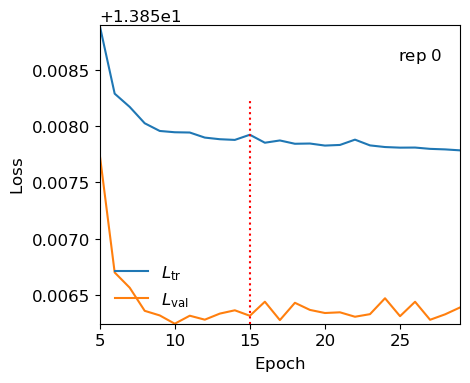

In [73]:
# Plots loss, only works if order = 'lin'
# c_name must only have on WC, since it must be linear

plt.rcParams.update({'font.size': 12})

loss_order = 'lin'
loss_c_name = 'ctGRe'

fig, _ = analyser.plot_loss_overview(loss_c_name, loss_order, xlim=5)

In [ ]:
# Edited theory ML4EFT calculations, so code can run
# WILL OUTPUT WARNIGNS FOR TRYING TO CALCUALTE THE LOG OF A NEGATIVE
# Some might be irrelevant, need to check 

from __future__ import division
from ml4eft.core.truth import tt_prod
import numpy as np
import matplotlib
from matplotlib import pyplot as plt
from matplotlib import rc
from scipy.integrate import quad, dblquad
from scipy import integrate
import pylhe

mt = 0.17276
s = 14 ** 2
Gf = 0.000011663787
v = 1 / np.sqrt(Gf * np.sqrt(2)) * 10 ** -3
asQCD = 0.1179
LambdaSMEFT = 1
pb_convert = 3.894E2
yt = 1
try:
    import lhapdf

    p = lhapdf.mkPDF("NNPDF31_lo_as_0118", 0)
except ImportError:
    print("lhapdf not found: exact models will not be available")

class crossSectionSMEFT:
    def sigma_part_gg(self, hats, ctGRe, cut, order):
        if np.sqrt(hats) == 2 * mt:
            return 0

        sqrt = np.sqrt(1 - 4 * mt ** 2 / hats)
        kappa_11 = ((v ** 2 * yt ** 2 * asQCD) / (24 * LambdaSMEFT ** 4 * hats ** 3)) * (
                6 * np.sqrt(hats ** 5 * (hats - 4 * mt ** 2)) + hats * mt ** 2 * (
                -3 * np.sqrt(hats * (hats - 4 * mt ** 2)) - 8 * hats * np.log(1 - sqrt) + 8 * hats * np.log(sqrt + 1)))
        kappa_1 = (np.sqrt(np.pi) * v * yt * mt * asQCD) / (6 * LambdaSMEFT ** 2 * hats ** 2 * np.sqrt(2)) * (
                9 * np.sqrt(hats * asQCD * (hats - 4 * mt ** 2)) + 8 * hats * np.sqrt(asQCD) * (
                np.log(1 - np.sqrt(1 - 4 * mt ** 2 / hats)) - np.log(np.sqrt(1 - 4 * mt ** 2 / hats) + 1)))
        sm = (-np.pi * asQCD ** 2) / (12 * hats ** 3) * (
                4 * mt ** 4 * (np.log(1 - sqrt) - np.log(sqrt + 1)) + mt ** 2 * (
                31 * np.sqrt(hats * (hats - 4 * mt ** 2)) + 16 * hats * np.log(1 - sqrt) - 16 * hats * np.log(
            sqrt + 1)) + hats * (7 * np.sqrt(hats * (hats - 4 * mt ** 2)) + 4 * hats * np.log(
            1 - sqrt) - 4 * hats * np.log(sqrt + 1)))

        if order is None:
            return sm
        elif order == 'lin':
            return sm + ctGRe * kappa_1
        elif order == 'quad':
            return sm + ctGRe ** 2 * kappa_11
            
    def sigma_part_qq(self, hats, cuGRe, ctu8, order):
        if np.sqrt(hats)== 2 * mt:
            return 0

        sqrt = np.sqrt(1 - 4 * mt ** 2 / hats)
        kappa_11 = sqrt * (8 * np.pi * v ** 2 * yt ** 2 * asQCD * (8 * mt ** 2 + hats)) / (
                108 * np.pi * LambdaSMEFT ** 4 * hats)

        # kappa_22 = (2.0 / 9.0) * sqrt * (hats - mt ** 2) / (48 * np.pi * LambdaSMEFT ** 4)
        # kappa_22 = sqrt * (hats - mt ** 2) / (48 * np.pi * LambdaSMEFT ** 4)
        kappa_22 = (2.0 / 9.0) * (hats * sqrt - mt ** 2 * sqrt) / (12 * 4 * np.pi * LambdaSMEFT ** 4)

        kappa_1 = - (8 * np.sqrt(2 * np.pi) * v * mt * asQCD ** (3 / 2) * sqrt) / (9 * hats * LambdaSMEFT ** 2)
        kappa_2 = asQCD * sqrt * (2 * mt ** 2 + hats) / (27 * hats * LambdaSMEFT ** 2)
        sm = (8 * np.pi * asQCD ** 2 * (2 * mt ** 2 + hats) * sqrt) / (27 * hats ** 2)

        if order is None:
            return sm
        elif order == 'lin':
            return sm + cuGRe * kappa_1 + ctu8 * kappa_2
        elif order == 'quad':
            return sm + cuGRe ** 2 * kappa_11 + ctu8 ** 2 * kappa_22
xsec = crossSectionSMEFT()



def weight(sqrts, mu, x1, x2, c, order):
    ctGRe, cut = c
    hats = sqrts ** 2

    w_e = (xsec.sigma_part_gg(hats, ctGRe, cut, order)) * (p.xfxQ(21, x1, mu) * p.xfxQ(21, x2, mu))

    w_e += (xsec.sigma_part_qq(hats, ctGRe, 0, order)) * (
            p.xfxQ(1, x1, mu) * p.xfxQ(-1, x2, mu) +
            p.xfxQ(1, x2, mu) * p.xfxQ(-1, x1, mu) +
            p.xfxQ(3, x1, mu) * p.xfxQ(-3, x2, mu) +
            p.xfxQ(3, x2, mu) * p.xfxQ(-3, x1, mu) +
            p.xfxQ(5, x1, mu) * p.xfxQ(-5, x2, mu) +
            p.xfxQ(5, x2, mu) * p.xfxQ(-5, x1, mu)
    )

    w_e += (xsec.sigma_part_qq(hats, ctGRe, cut, order)) * (
            p.xfxQ(2, x1, mu) * p.xfxQ(-2, x2, mu) +
            p.xfxQ(2, x2, mu) * p.xfxQ(-2, x1, mu) +
            p.xfxQ(4, x1, mu) * p.xfxQ(-4, x2, mu) +
            p.xfxQ(4, x2, mu) * p.xfxQ(-4, x1, mu)
    )

    return w_e

v_weight = np.vectorize(weight, otypes=[np.float])
v_weight.excluded.add(4)

def new_dsigma_dmtt_dy(y, mtt, c=None, order=None):
    mtt = mtt/1000 # ML4EFT needs the values in TeV but using GeV data
    
    s = 14 ** 2

    if c is None:
        c = np.zeros(2)
    if mtt == 2 * mt: return 0  # if at threshold return zero
    if y < np.log(np.sqrt(s) / (mtt)):  # check whether x = {mtt, y} falls inside the physically allowed region
        x1 = mtt / np.sqrt(s) * np.exp(y)
        x2 = mtt / np.sqrt(s) * np.exp(-y)
        dsigma_dmtt_dy = 2 * mtt / s * v_weight(mtt, 91.188, x1, x2, c, order) / (x1 * x2)
        return pb_convert * dsigma_dmtt_dy
    else:
        return 0

def new_likelihood_ratio_truth(events, c, features, process, order=None):
    n_features = len(features)

    if process == 'tt':
        c = np.array([c['ctGRe'], c['ctu8']])
        if n_features == 1:
            dsigma_0 = [tt_prod.dsigma_dmtt(*x[features], c, order) for _, x in events.iterrows()]  # EFT
            dsigma_1 = [tt_prod.dsigma_dmtt(*x[features]) for _, x in
                        events.iterrows()]  # SM
        elif n_features == 2:
            dsigma_0 = [new_dsigma_dmtt_dy(*x[features], c, order) for _, x in
                        events.iterrows()]  # EFT
            dsigma_1 = [new_dsigma_dmtt_dy(*x[features]) for _, x in
                        events.iterrows()]  # SM
        elif n_features == 3:
            dsigma_0 = [tt_prod.dsigma_dmtt_dy_dpt(*x[features], c, order) for
                        index, x in
                        events.iterrows()]  # EFT
            dsigma_1 = [tt_prod.dsigma_dmtt_dy_dpt(*x[features]) for
                        index, x in
                        events.iterrows()]  # SM

    dsigma_0 = np.array(dsigma_0, dtype = float)
    dsigma_1 = np.array(dsigma_1, dtype = float)

    ratio = np.divide(dsigma_0, dsigma_1, out=np.zeros_like(dsigma_0), where=dsigma_1 != 0)

    return ratio.flatten()

def edited_likelihood_ratio_nn(c, df=None, epoch=-1):

    return analyser.likelihood_ratio_nn(c, df)

def new_point_by_point_comp_med(df, c, features, process, order, ax, text=None):

    r_nn = edited_likelihood_ratio_nn(c, df=df)
    tau_nn = np.log(r_nn)

    r_truth = new_likelihood_ratio_truth(df, c, features, process, order)
    tau_truth = np.log(r_truth)

    fig = plt.figure(figsize=(8, 8))
    x = np.linspace(-0.4, 1.7, 100)

    ax.scatter(tau_truth, np.median(tau_nn, axis=0), s=2, color='red')
    ax.plot(x, x, linestyle='dashed', color='grey')
    ax.set_xlabel(r'$\log r(x, c)^{\rm{Unbinned}\;\rm{exact}}$')
    ax.set_ylabel(r'$\log r(x, c)^{\rm{Unbinned}\;\rm{ML}}$')
    ax.set_xlim((np.min(x), np.max(x)))
    ax.set_ylim((np.min(x), np.max(x)))

    if text is not None:
        ax.text(0.95, 0.1, text,
                horizontalalignment='right',
                verticalalignment='center',
                transform=ax.transAxes)

    fig.tight_layout()

LHAPDF 6.5.4 loading /depot/cms/purdue-af/lhapdf/share/LHAPDF/NNPDF31_lo_as_0118/NNPDF31_lo_as_0118_0000.dat
NNPDF31_lo_as_0118 PDF set, member #0, version 1; LHAPDF ID = 315000


/tmp/ipykernel_1040/3537500293.py:34: RuntimeWarning: invalid value encountered in sqrt
  sqrt = np.sqrt(1 - 4 * mt ** 2 / hats)
/tmp/ipykernel_1040/3537500293.py:36: RuntimeWarning: invalid value encountered in sqrt
  6 * np.sqrt(hats ** 5 * (hats - 4 * mt ** 2)) + hats * mt ** 2 * (
/tmp/ipykernel_1040/3537500293.py:37: RuntimeWarning: invalid value encountered in sqrt
  -3 * np.sqrt(hats * (hats - 4 * mt ** 2)) - 8 * hats * np.log(1 - sqrt) + 8 * hats * np.log(sqrt + 1)))
/tmp/ipykernel_1040/3537500293.py:39: RuntimeWarning: invalid value encountered in sqrt
  9 * np.sqrt(hats * asQCD * (hats - 4 * mt ** 2)) + 8 * hats * np.sqrt(asQCD) * (
/tmp/ipykernel_1040/3537500293.py:40: RuntimeWarning: invalid value encountered in sqrt
  np.log(1 - np.sqrt(1 - 4 * mt ** 2 / hats)) - np.log(np.sqrt(1 - 4 * mt ** 2 / hats) + 1)))
/tmp/ipykernel_1040/3537500293.py:43: RuntimeWarning: invalid value encountered in sqrt
  31 * np.sqrt(hats * (hats - 4 * mt ** 2)) + 16 * hats * np.log(1 - sqrt) - 16

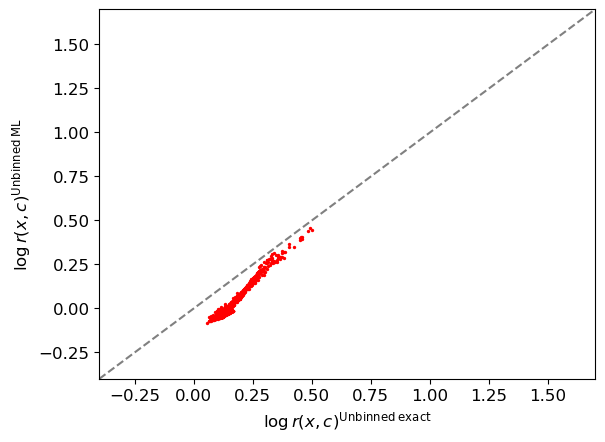

<Figure size 800x800 with 0 Axes>

In [77]:
# Comparison plot of a ML model, only works for mttbar and Y features

fig, ax = plt.subplots()

new_point_by_point_comp_med(df_sm.sample(n=10000, random_state=2112),
                        {'ctGRe': 2, 'ctu8': 0},
                        ['gen_ttbar_rapidity','gen_ttbar_mass'],
                        'tt', 'quad', ax)

Limit Plots

In [78]:
# json for using ML4EFT limit calculations
# "Order", quad or lin
# "Process", ttparton
# with additional file called info.txt that has the WC value, i.e. "2"
# "Mode", how the limit is calculated: nn, binned, truth
# "Features", features used in theory calculations (only needed for binned and truth) must be mttbar and Y
# "nlive", does nothing, needed for pymultinest but im not using it
# "lumi", luminocity
# "bins", when mode is binned, selects the binns to scan over
# "path_to_models", location of the ML models, files used must have format: {path to dir}/model_{WC name 1}_{WC name 2}
# "path_to_theory_pred" files used must have format: {path to dir}/ttparton_{WC name 1}_{WC name 2}/events_0.pkl
# "Observed_data_path" i am using the SM data that is used in the theory path, this might not be the most correct
# "Results_path" not needed


optimizer_json = {
              "fit_id": "test_fit",
              "order": "quad",
              "process": "ttparton",
              "mode": "nn",
              "th_features": ['gen_ttbar_rapidity','gen_ttbar_mass'],
            
              "nlive": 1000,
              "lumi": 300, 

              "bins": {'gen_ttbar_rapidity':[-3.0,-1.5,0,1.5,3.0],
                       'gen_ttbar_mass': [1450,2500,np.inf],
              },
            
              "path_to_models": "/depot/cms/top/jpittard/Purdue_Analysis_EFT/EFT_param_classifier/model/quad_limit_ctGRe_ctu8_mtt_y/",
            
              "path_to_theory_pred": "/depot/cms/top/jpittard/Purdue_Analysis_EFT/pickel_files/limit_sm_quad_pickles",
            
              "observed_data_path": "/depot/cms/top/jpittard/Purdue_Analysis_EFT/pickel_files/ttparton_sm/events_0.pkl.gz",
            
              "results_path": "limit_results/"
            }

In [79]:
# calculates the limit for the two WCs 

optimizer = optimize.Optimize(optimizer_json, coeff = ['ctGRe','ctu8'], rep = None)
optimizer

In [80]:
# check if the data was loaded in as expected

optimizer.th_pred.th_dict

defaultdict(dict,
            {'sm': 366.6125,
             'quad': {'ctu8_ctGRe': 80.83575439453125,
              'ctGRe_ctu8': 50.06028747558594,
              'ctGRe_ctGRe': 16.931243896484375,
              'ctu8_ctu8': 6.310546875}})

In [81]:
#Calculates the limit space for the two WC
#spans over values for c1 and c2

c1_val = np.linspace(-1,1,30)
c2_val = np.linspace(-1,1,30)

liklihood = np.zeros((len(c1_val),len(c2_val)))

for i, c1 in enumerate(c1_val):
    for j, c2 in enumerate(c2_val):
        cube = np.array([c1,c2])

        liklihood[i,j] = optimizer.log_like_nn(cube)  # limit for NN
        #liklihood[i,j] = optimizer.log_like_binned(cube)  # limit for binned
        #liklihood[i,j] = optimizer.log_like_truth(cube)  # limit for theory

    print(f"Finished i = {i} interval")

done with i = 0 interval
done with i = 1 interval
done with i = 2 interval
done with i = 3 interval
done with i = 4 interval
done with i = 5 interval
done with i = 6 interval
done with i = 7 interval
done with i = 8 interval
done with i = 9 interval
done with i = 10 interval
done with i = 11 interval
done with i = 12 interval
done with i = 13 interval
done with i = 14 interval
done with i = 15 interval
done with i = 16 interval
done with i = 17 interval
done with i = 18 interval
done with i = 19 interval
done with i = 20 interval
done with i = 21 interval
done with i = 22 interval
done with i = 23 interval
done with i = 24 interval
done with i = 25 interval
done with i = 26 interval
done with i = 27 interval
done with i = 28 interval
done with i = 29 interval


[[-16.51360561 -16.5045019  -16.4934205  -16.48015956 -16.46450808
  -16.44624377 -16.42513344 -16.40093126 -16.37337819 -16.34219956
  -16.30710389 -16.26777964 -16.22389178 -16.17507712 -16.12093911
  -16.06104008 -15.99489196 -15.92194421 -15.84156814 -15.75303621
  -15.65549534 -15.54793039 -15.42911454 -15.29754082 -15.15132338
  -14.98805536 -14.80459218 -14.59671354 -14.35856996 -14.08171847]
 [-16.49703416 -16.49226787 -16.48551652 -16.47658408 -16.46526566
  -16.45134733 -16.43460569 -16.41480698 -16.39170648 -16.36504693
  -16.33455719 -16.2999504  -16.26092038 -16.21713898 -16.16825123
  -16.11386937 -16.05356562 -15.98686257 -15.91322103 -15.83202431
  -15.74255748 -15.64398022 -15.5352905  -15.41527434 -15.28243762
  -15.13490714 -14.97028764 -14.78544655 -14.5761758  -14.33663722]
 [-16.47892091 -16.47852493 -16.47611815 -16.47150968 -16.46450102
  -16.45488661 -16.44245221 -16.42697572 -16.40822598 -16.38596165
  -16.3599306  -16.32986813 -16.29549461 -16.25651292 -16.21

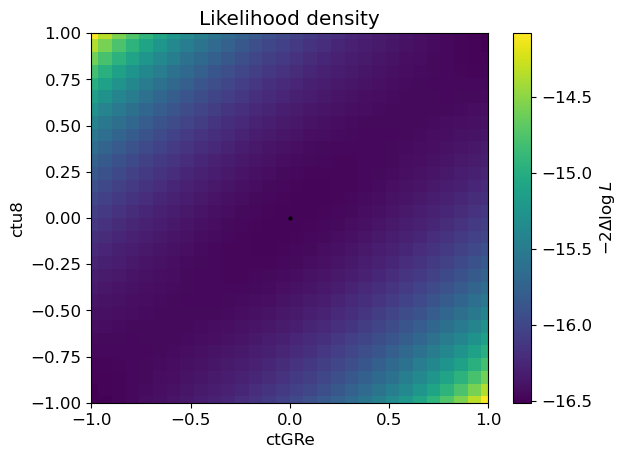

In [97]:
# Plots the 68% and 95% confidence interval

sm = [0]

liklihood_max = np.argmax(liklihood)

q_test = -2 * np.log(abs(liklihood / liklihood_max)) #test statistic
print(q_test)

plt.contour(c1_val,c2_val,q_test.T, levels = [2.30,5.99])
plt.xlabel("ctGRe")
plt.ylabel("ctu8")
plt.xlim(-1,1)
plt.ylim(-1,1)

plt.pcolormesh( c1_val, c2_val, q_test.T,)
plt.xlabel("ctGRe")
plt.ylabel("ctu8")

plt.title("Likelihood density")
plt.colorbar(label="$-2\Delta \log{L}$")
plt.scatter(sm,sm,color = 'black', s = 4)
plt.show()